# MedMCQA Fractionwise KL Divergence Plotting

This notebook loads the aggregated MedMCQA results and plots fractionwise KL divergence values comparing MCal_CE vs MCal_CE_Uncond.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from pathlib import Path

# Use default matplotlib color cycle (blue/orange)
matplotlib.rcParams['axes.prop_cycle'] = matplotlib.cycler(color=['#1f77b4', '#ff7f0e'])

# Figure dimensions - publication ready
fig_width = 3.0   # inches per plot (wider for fractionwise data)
fig_height = 2.4  # inches per plot

# Font sizes
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

## Load MedMCQA Results Data

In [4]:
# Load the aggregated results JSON file
results_path = Path("/home/antonxue/shailesh/MCal/results/json/aggregated_results_medmcqa.json")

# Check if file exists
if not results_path.exists():
    print(f"❌ Results file not found at: {results_path}")
    print("Please run the MedMCQA benchmark first to generate results.")
    print("Command: python medmcqa_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
else:
    print(f"✅ Loading results from: {results_path}")
    
    with open(results_path, 'r') as f:
        results = json.load(f)
    
    print(f"Available methods: {list(results.keys())}")

✅ Loading results from: /home/antonxue/shailesh/MCal/results/json/aggregated_results_medmcqa.json
Available methods: ['mcal_ce_uncond', 'mcal_ce']


In [5]:
# Check if both mcal_ce and mcal_ce_uncond methods exist in results
methods_to_compare = ['mcal_ce', 'mcal_ce_uncond']
missing_methods = [method for method in methods_to_compare if method not in results]

if missing_methods:
    print(f"❌ Missing methods: {missing_methods}")
    print(f"Available methods: {list(results.keys())}")
    print("Please run the MedMCQA benchmark with both mcal_ce and mcal_ce_uncond methods first.")
    print("Command: python medmcqa_kl_benchmark.py --methods mcal_ce mcal_ce_uncond")
else:
    print("✅ Both mcal_ce and mcal_ce_uncond methods found!")
    
    # Extract fractionwise data for both methods
    methods_data = {}
    
    for method in methods_to_compare:
        method_results = results[method]
        
        if 'fraction_wise_results_transformed' in method_results:
            fraction_data = method_results['fraction_wise_results_transformed']
            
            methods_data[method] = {
                'mean_argmax': np.array(fraction_data['mean_argmax']),
                'std_argmax': np.array(fraction_data['std_argmax'])
            }
            
            print(f"✅ {method} fractionwise data loaded successfully")
        else:
            print(f"❌ Fractionwise results not found for {method}")
            print(f"Available keys: {list(method_results.keys())}")
    
    # Create fraction labels based on actual data
    if methods_data:
        # Use the first method to determine number of fractions
        first_method = list(methods_data.keys())[0]
        n_fractions = len(methods_data[first_method]['mean_argmax'])
        fractions = np.arange(n_fractions)  # Use actual indices
        fraction_labels = [f"{i}" for i in range(n_fractions)]  # 0, 1, 2, etc.
        
        print(f"Number of fractions: {n_fractions}")
        print(f"Fraction indices: 0 to {n_fractions-1}")
        
        # Print summary for both methods
        for method in methods_to_compare:
            if method in methods_data:
                data = methods_data[method]
                print(f"\n{method.upper()} SUMMARY:")
                print(f"   Mean KL (argmax) range: {data['mean_argmax'].min():.6f} to {data['mean_argmax'].max():.6f}")

✅ Both mcal_ce and mcal_ce_uncond methods found!
✅ mcal_ce fractionwise data loaded successfully
✅ mcal_ce_uncond fractionwise data loaded successfully
Number of fractions: 10
Fraction indices: 0 to 9

MCAL_CE SUMMARY:
   Mean KL (argmax) range: 0.000000 to 0.000000

MCAL_CE_UNCOND SUMMARY:
   Mean KL (argmax) range: 0.002712 to 0.538680


## Plot MCal_CE vs MCal_CE_Uncond Fractionwise KL Divergence (Argmax Only)

Saving plots to: /home/antonxue/shailesh/MCal/experiments/language/figures


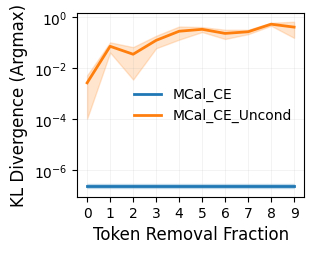

Saved: /home/antonxue/shailesh/MCal/experiments/language/figures/medmcqa_mcal_comparison_fractionwise_kl_argmax_log.pdf

✅ MedMCQA MCal comparison log plot saved to /home/antonxue/shailesh/MCal/experiments/language/figures/


In [ ]:
# Create comparison plot for MCal_CE vs MCal_CE_Uncond with log scale (Argmax only)
if 'methods_data' in locals() and len(methods_data) >= 2:
    # Ensure output directory exists
    output_dir = 'figures'
    os.makedirs(output_dir, exist_ok=True)
    abs_output_dir = Path(output_dir).absolute()
    print(f"Saving plots to: {abs_output_dir}")
    
    # Get data for both methods
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Plot: KL Divergence (Argmax/One-hot) Comparison - LOG SCALE
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    
    # MCal_CE line and confidence band
    ax.plot(fractions, mcal_ce_data['mean_argmax'], '-', 
            label='Conditioned MCal', linewidth=2, color='#1f77b4')
    ax.fill_between(fractions, 
                    mcal_ce_data['mean_argmax'] - 0.5*mcal_ce_data['std_argmax'], 
                    mcal_ce_data['mean_argmax'] + 0.5*mcal_ce_data['std_argmax'],
                    alpha=0.2, color='#1f77b4')
    
    # MCal_CE_Uncond line and confidence band
    ax.plot(fractions, mcal_ce_uncond_data['mean_argmax'], '-', 
            label='Unconditioned MCal', linewidth=2, color='#ff7f0e')
    ax.fill_between(fractions, 
                    mcal_ce_uncond_data['mean_argmax'] - 0.75*mcal_ce_uncond_data['std_argmax'], 
                    mcal_ce_uncond_data['mean_argmax'] + 0.75*mcal_ce_uncond_data['std_argmax'],
                    alpha=0.2, color='#ff7f0e')
    
    ax.set_xlabel('Ablation Fraction')
    ax.set_ylabel('Missingness Bias')
    ax.set_yscale('log')  # LOG SCALE
    ax.legend(loc='best', frameon=False)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.tick_params(axis='both', which='major')
    
    # Set x-axis ticks
    ax.set_xticks(fractions)
    ax.set_xticklabels(fraction_labels)
    
    plt.tight_layout(pad=0.2)
    plt.savefig(f'{output_dir}/medmcqa_mcal_comparison_fractionwise_kl_argmax_log.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {abs_output_dir}/medmcqa_mcal_comparison_fractionwise_kl_argmax_log.pdf")
    
    print(f"\n✅ MedMCQA MCal comparison log plot saved to {abs_output_dir}/")
    
else:
    print("❌ No comparison data available to plot")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

## MCal_CE vs MCal_CE_Uncond Comparison Statistics

In [ ]:
# Detailed comparison statistics between MCal_CE and MCal_CE_Uncond
if 'methods_data' in locals() and len(methods_data) >= 2:
    print("📊 MEDMCQA: MCAL_CE vs MCAL_CE_UNCOND FRACTIONWISE KL DIVERGENCE COMPARISON")
    print("=" * 80)
    
    mcal_ce_data = methods_data['mcal_ce']
    mcal_ce_uncond_data = methods_data['mcal_ce_uncond']
    
    # Argmax KL Divergence Comparison
    print(f"\n🎯 ARGMAX/ONE-HOT KL DIVERGENCE COMPARISON:")
    print(f"{'Method':<20} {'Min':<12} {'Max':<12} {'Mean':<12} {'Std':<12}")
    print("-" * 70)
    print(f"{'MCal_CE':<20} {mcal_ce_data['mean_argmax'].min():<12.6f} {mcal_ce_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_data['mean_argmax'].mean():<12.6f} {mcal_ce_data['mean_argmax'].std():<12.6f}")
    print(f"{'MCal_CE_Uncond':<20} {mcal_ce_uncond_data['mean_argmax'].min():<12.6f} {mcal_ce_uncond_data['mean_argmax'].max():<12.6f} "
          f"{mcal_ce_uncond_data['mean_argmax'].mean():<12.6f} {mcal_ce_uncond_data['mean_argmax'].std():<12.6f}")
    
    # Calculate improvement (negative means MCal_CE_Uncond is worse, which is expected)
    argmax_improvement = ((mcal_ce_data['mean_argmax'].mean() - mcal_ce_uncond_data['mean_argmax'].mean()) 
                         / mcal_ce_uncond_data['mean_argmax'].mean()) * 100
    print(f"\n   → MCal_CE vs MCal_CE_Uncond improvement: {argmax_improvement:+.2f}%")
    
    # Fraction-wise comparison - show largest differences
    print(f"\n📈 FRACTION-WISE ANALYSIS:")
    argmax_diff = mcal_ce_uncond_data['mean_argmax'] - mcal_ce_data['mean_argmax']  # Uncond - CE (should be positive)
    
    # Find fractions with largest differences
    largest_diff_fraction = np.argmax(argmax_diff)
    
    print(f"   Largest difference at fraction {largest_diff_fraction}:")
    print(f"      MCal_CE: {mcal_ce_data['mean_argmax'][largest_diff_fraction]:.6f}")
    print(f"      MCal_CE_Uncond: {mcal_ce_uncond_data['mean_argmax'][largest_diff_fraction]:.6f}")
    print(f"      Difference: {argmax_diff[largest_diff_fraction]:.6f}")
    
    # Show trends
    ce_argmax_trend = "increasing" if mcal_ce_data['mean_argmax'][-1] > mcal_ce_data['mean_argmax'][0] else "decreasing"
    uncond_argmax_trend = "increasing" if mcal_ce_uncond_data['mean_argmax'][-1] > mcal_ce_uncond_data['mean_argmax'][0] else "decreasing"
    
    print(f"\n📊 TRENDS ACROSS TOKEN REMOVAL FRACTIONS:")
    print(f"   MCal_CE Argmax KL: {ce_argmax_trend} ({mcal_ce_data['mean_argmax'][0]:.6f} → {mcal_ce_data['mean_argmax'][-1]:.6f})")
    print(f"   MCal_CE_Uncond Argmax KL: {uncond_argmax_trend} ({mcal_ce_uncond_data['mean_argmax'][0]:.6f} → {mcal_ce_uncond_data['mean_argmax'][-1]:.6f})")
    
else:
    print("❌ No comparison data available for detailed statistics")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")

## Export Comparison Data

In [ ]:
# Export the comparison data in a nice table format
if 'methods_data' in locals() and len(methods_data) >= 2:
    import pandas as pd
    
    # Create comprehensive comparison DataFrame
    comparison_data = []
    
    for i in range(len(fractions)):
        comparison_data.append({
            'Fraction_Index': i,
            'MCal_CE_Argmax_Mean': methods_data['mcal_ce']['mean_argmax'][i],
            'MCal_CE_Argmax_Std': methods_data['mcal_ce']['std_argmax'][i],
            'MCal_CE_Uncond_Argmax_Mean': methods_data['mcal_ce_uncond']['mean_argmax'][i],
            'MCal_CE_Uncond_Argmax_Std': methods_data['mcal_ce_uncond']['std_argmax'][i],
            'Difference_Uncond_minus_CE': methods_data['mcal_ce_uncond']['mean_argmax'][i] - methods_data['mcal_ce']['mean_argmax'][i]
        })
    
    df_comparison = pd.DataFrame(comparison_data)
    
    print("📋 MEDMCQA: MCAL_CE vs MCAL_CE_UNCOND DETAILED COMPARISON:")
    print(df_comparison.round(6).to_string(index=False))
    
    # Save to CSV
    csv_path = Path("./results/medmcqa_mcal_comparison_fractionwise_data.csv")
    df_comparison.to_csv(csv_path, index=False)
    print(f"\n✅ Detailed comparison data saved to: {csv_path}")
    
    # Summary statistics
    print(f"\n📊 SUMMARY STATISTICS:")
    print(f"   Average difference (Uncond - CE): {df_comparison['Difference_Uncond_minus_CE'].mean():+.6f}")
    print(f"   Largest difference: {df_comparison['Difference_Uncond_minus_CE'].max():+.6f} (Fraction {df_comparison.loc[df_comparison['Difference_Uncond_minus_CE'].idxmax(), 'Fraction_Index']})")
    print(f"   MCal_CE consistently lower KL divergence: {'✅ Yes' if df_comparison['Difference_Uncond_minus_CE'].min() >= 0 else '❌ No'}")
    
else:
    print("❌ No comparison data available to export")
    if 'methods_data' in locals():
        print(f"Available methods: {list(methods_data.keys())}")
    else:
        print("No methods data loaded")